# Nyström Approximation for KernCD

The exact Christoffel-Darboux function requires an $m \times m$ kernel matrix and $O(m^3)$ Cholesky factorization.
The Nyström approximation uses $r \ll m$ landmark points to approximate the kernel matrix,
reducing fit cost to $O(mr^2 + r^3)$ and prediction to $O(br^2)$.

In [90]:
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import rbf_kernel
from scipy.stats import pearsonr
from scipy.linalg import solve_triangular, cholesky

from algs.kern_cd import KernCD
from algs.kernels import RBF

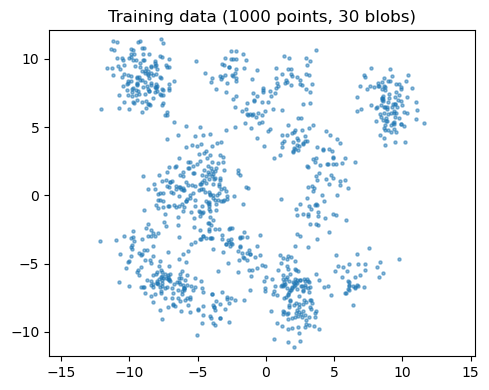

In [122]:
# Generate 2D blob data
n_clusters = 30
X_train, _ = make_blobs(n_samples=1000, centers=n_clusters, random_state=42, cluster_std=1.0)

# Evaluation grid
pad = 2.0
x_min, x_max = X_train[:, 0].min() - pad, X_train[:, 0].max() + pad
y_min, y_max = X_train[:, 1].min() - pad, X_train[:, 1].max() + pad
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
X_grid = np.column_stack([xx.ravel(), yy.ravel()])

plt.figure(figsize=(5, 4))
plt.scatter(X_train[:, 0], X_train[:, 1], s=5, alpha=0.5)
plt.title(f'Training data ({len(X_train)} points, {n_clusters} blobs)')
plt.axis('equal')
plt.tight_layout()

In [123]:
# Fix gamma for all experiments
kernel = RBF(gamma='median')
kernel.fit(X_train)
gamma_fixed = kernel.gamma
print(f'gamma (median heuristic): {gamma_fixed:.4f}')

# Exact CD
cd_exact = KernCD(RBF(gamma=gamma_fixed), reg='adaptive')
t0 = time.perf_counter()
cd_exact.fit(X_train)
t_fit_exact = time.perf_counter() - t0

t0 = time.perf_counter()
scores_exact = cd_exact.predict(X_grid)
t_pred_exact = time.perf_counter() - t0

lam_exact = cd_exact.lam_
print(f'Exact: fit={t_fit_exact:.3f}s, predict={t_pred_exact:.3f}s, λ={lam_exact:.2e}')

gamma (median heuristic): 0.0045
Exact: fit=3.214s, predict=0.421s, λ=1.00e-03


## Nyström Approximation

Given $m$ training points $X$ and $r$ landmarks $L$, the Nyström approximation replaces the full $m \times m$ kernel matrix with a low-rank approximation:
$$K \approx K_{mr} K_{rr}^{-1} K_{mr}^\top$$

**Fit** ($O(mr^2 + r^3)$):
1. $L_{rr} = \text{chol}(K_{rr} + \varepsilon I)$
2. $\Phi = K_{mr} L_{rr}^{-\top}$ — Nyström features ($m \times r$)
3. $G = \Phi^\top \Phi$ — Gram in feature space ($r \times r$)
4. Determine $\lambda$ from eigenvalues of $G$, set $\mu = \lambda m$
5. $L_G = \text{chol}(G + \mu I)$

**Predict** ($O(br^2)$ for $b$ test points):
1. $k_{xr} = k(x, L)$, $k_{\text{diag}} = k(x, x)$
2. $\varphi_x = L_{rr}^{-1} k_{xr}^\top$ — forward solve
3. $z = L_G^{-1} \varphi_x$ — forward solve
4. $\text{CD}(x) = \left(k(x,x) - \|\varphi_x\|^2 + \mu \|z\|^2\right) / \lambda$

The $-\|\varphi_x\|^2$ term is the Nyström self-kernel approximation; $\mu\|z\|^2$ is the regularized projection in landmark space.

In [111]:
class NystromKernCD:
    """
    Nystrom-approximated Christoffel-Darboux function.

    Parameters
    ----------
    kernel : callable
        Kernel function with __call__(X, Y) and diag(X) methods.
    reg : {'adaptive', 'condition'} or float
        Regularization strategy (applied in the r-dimensional landmark space).
    landmarks : np.ndarray of shape (r, d)
        Landmark points for the Nystrom approximation.
    """

    def __init__(self, kernel, reg, landmarks):
        self.kernel = kernel
        self.reg = reg
        self.landmarks = np.asarray(landmarks)

    def fit(self, X):
        m = len(X)
        L = self.landmarks
        r = len(L)

        # Kernel matrices
        K_rr = self.kernel(L, L)          # (r, r)
        K_mr = self.kernel(X, L)          # (m, r)

        # Cholesky of K_rr
        eps = 1e-10 * np.trace(K_rr) / r
        self.L_rr = cholesky(K_rr + eps * np.eye(r), lower=True)  # (r, r)

        # Nystrom features: Phi = K_mr @ L_rr^{-T}  (m, r)
        Phi = solve_triangular(self.L_rr, K_mr.T, lower=True).T   # (m, r)

        # Gram matrix in feature space
        G = Phi.T @ Phi  # (r, r)

        # Determine lambda
        if isinstance(self.reg, (int, float)):
            self.lam_ = self.reg / m
        elif self.reg == 'adaptive':
            self.lam_ = self._lambda_adaptive(G, m)
        elif self.reg == 'condition':
            self.lam_ = self._lambda_condition(G, m)
        else:
            raise ValueError(f"Unknown reg: {self.reg}")

        mu = self.lam_ * m
        self.mu_ = mu

        # Cholesky of (G + mu I)
        self.L_G = cholesky(G + mu * np.eye(r), lower=True)  # (r, r)

        return self

    def predict(self, X):
        k_xr = self.kernel(X, self.landmarks)  # (b, r)
        k_diag = self.kernel.diag(X)            # (b,)

        # phi_x = L_rr^{-1} k_xr^T  ->  (r, b)
        phi_x = solve_triangular(self.L_rr, k_xr.T, lower=True)  # (r, b)

        # z = L_G^{-1} phi_x  ->  (r, b)
        z = solve_triangular(self.L_G, phi_x, lower=True)  # (r, b)

        # CD(x) = (k(x,x) - ||phi_x||^2 + mu * ||z||^2) / lambda
        phi_sq = np.sum(phi_x ** 2, axis=0)  # (b,)
        z_sq = np.sum(z ** 2, axis=0)         # (b,)

        return (k_diag - phi_sq + self.mu_ * z_sq) / self.lam_

    @staticmethod
    def _lambda_adaptive(G, m, kappa_target=1e3):
        r = G.shape[0]
        for log_lam in range(-14, 0):
            lam = 10.0 ** log_lam
            G_reg = G + lam * m * np.eye(r)
            try:
                cholesky(G_reg, lower=True)
                cond = np.linalg.cond(G_reg)
                if cond < kappa_target:
                    return lam
            except np.linalg.LinAlgError:
                continue
        return 1e-3

    @staticmethod
    def _lambda_condition(G, m, kappa_target=1e3):
        eigvals = np.linalg.eigvalsh(G)
        lmin, lmax = eigvals[0], eigvals[-1]
        num = lmax - kappa_target * lmin
        if num <= 0:
            return 1e-12
        return num / ((kappa_target - 1) * m)

In [124]:
# --- Uniform random landmarks ---
r = 30
rng = np.random.default_rng(0)
idx_uniform = rng.choice(len(X_train), size=r, replace=False)
L_uniform = X_train[idx_uniform]

kern_uniform = RBF(gamma=gamma_fixed)
kern_uniform.fit(X_train)

nys_uniform = NystromKernCD(kern_uniform, reg='adaptive', landmarks=L_uniform)
t0 = time.perf_counter()
nys_uniform.fit(X_train)
t_fit_uniform = time.perf_counter() - t0

t0 = time.perf_counter()
scores_uniform = nys_uniform.predict(X_grid)
t_pred_uniform = time.perf_counter() - t0

print(f'Uniform (r={r}): fit={t_fit_uniform:.3f}s, predict={t_pred_uniform:.3f}s')

Uniform (r=30): fit=0.002s, predict=0.016s


In [125]:
# --- KMeans landmarks ---
km = KMeans(n_clusters=r, random_state=0, n_init=10).fit(X_train)
L_kmeans = km.cluster_centers_

kern_kmeans = RBF(gamma=gamma_fixed)
kern_kmeans.fit(X_train)

nys_kmeans = NystromKernCD(kern_kmeans, reg='adaptive', landmarks=L_kmeans)
t0 = time.perf_counter()
nys_kmeans.fit(X_train)
t_fit_kmeans = time.perf_counter() - t0

t0 = time.perf_counter()
scores_kmeans = nys_kmeans.predict(X_grid)
t_pred_kmeans = time.perf_counter() - t0

print(f'KMeans (r={r}): fit={t_fit_kmeans:.3f}s, predict={t_pred_kmeans:.3f}s')

KMeans (r=30): fit=0.002s, predict=0.013s


In [126]:
# --- Leverage-weighted landmarks ---
# Pilot: fit with 40 random landmarks to get approximate CD scores on training data
idx_pilot = rng.choice(len(X_train), size=100, replace=False)
L_pilot = X_train[idx_pilot]

kern_pilot = RBF(gamma=gamma_fixed)
kern_pilot.fit(X_train)
nys_pilot = NystromKernCD(kern_pilot, reg='adaptive', landmarks=L_pilot)
nys_pilot.fit(X_train)
pilot_scores = nys_pilot.predict(X_train)

# Approximate leverage: ℓ_i = 1 - λ·CD(x_i)  (for RBF where k(x,x)=1)
# Sample landmarks proportional to leverage scores (low CD = high leverage).
leverage = np.maximum(1.0 - nys_pilot.lam_ * pilot_scores, 1e-12)
probs = leverage / leverage.sum()
idx_leverage = rng.choice(len(X_train), size=r, replace=False, p=probs)
L_leverage = X_train[idx_leverage]
print(f'Leverage-weighted: median leverage={np.median(leverage):.4f}, selected r={r}')

kern_leverage = RBF(gamma=gamma_fixed)
kern_leverage.fit(X_train)
nys_leverage = NystromKernCD(kern_leverage, reg='adaptive', landmarks=L_leverage)
t0 = time.perf_counter()
nys_leverage.fit(X_train)
t_fit_leverage = time.perf_counter() - t0

t0 = time.perf_counter()
scores_leverage = nys_leverage.predict(X_grid)
t_pred_leverage = time.perf_counter() - t0

print(f'Leverage-weighted (r={r}): fit={t_fit_leverage:.3f}s, predict={t_pred_leverage:.3f}s')

Leverage-weighted: median leverage=0.9922, selected r=30
Leverage-weighted (r=30): fit=0.002s, predict=0.013s


In [127]:
# --- Quality metrics ---
def quality_metrics(scores_approx, scores_ref):
    """Pearson correlation and relative RMSE of log-scores vs reference."""
    log_ref = np.log1p(scores_ref)
    log_approx = np.log1p(scores_approx)
    corr, _ = pearsonr(log_ref, log_approx)
    rel_rmse = np.sqrt(np.mean((log_ref - log_approx) ** 2)) / (np.std(log_ref) + 1e-12)
    return corr, rel_rmse

for name, sc in [('Uniform', scores_uniform), ('KMeans', scores_kmeans), ('Leverage', scores_leverage)]:
    corr, rrmse = quality_metrics(sc, scores_exact)
    print(f'{name:15s}  corr={corr:.4f}  rel_RMSE={rrmse:.4f}')

Uniform          corr=1.0000  rel_RMSE=0.0038
KMeans           corr=1.0000  rel_RMSE=0.0006
Leverage         corr=1.0000  rel_RMSE=0.0115


Text(0.5, 0.98, 'Christoffel-Darboux Scores: Exact vs Nyström')

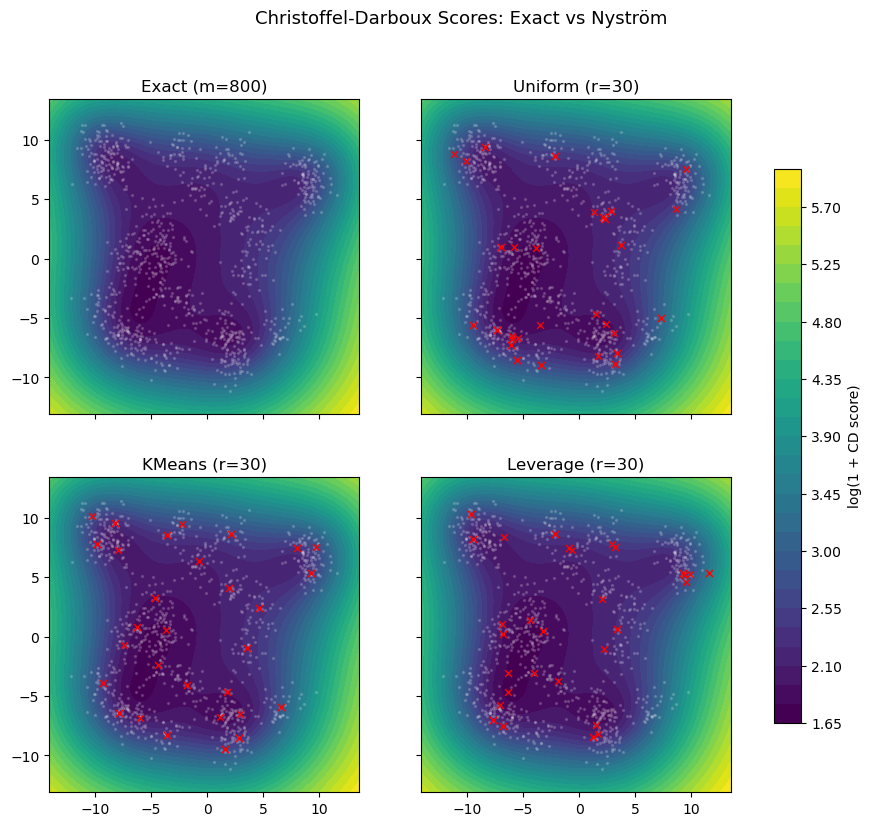

In [128]:
# --- 2x2 contour plot ---
log_exact = np.log1p(scores_exact).reshape(xx.shape)
log_uniform = np.log1p(scores_uniform).reshape(xx.shape)
log_kmeans = np.log1p(scores_kmeans).reshape(xx.shape)
log_leverage = np.log1p(scores_leverage).reshape(xx.shape)

vmin = min(log_exact.min(), log_uniform.min(), log_kmeans.min(), log_leverage.min())
vmax = max(log_exact.max(), log_uniform.max(), log_kmeans.max(), log_leverage.max())

fig, axes = plt.subplots(2, 2, figsize=(11, 9), sharex=True, sharey=True)
titles = ['Exact (m=800)', f'Uniform (r={r})', f'KMeans (r={r})', f'Leverage (r={r})']
grids = [log_exact, log_uniform, log_kmeans, log_leverage]
landmarks_list = [None, L_uniform, L_kmeans, L_leverage]

for ax, title, grid, lm in zip(axes.flat, titles, grids, landmarks_list):
    cf = ax.contourf(xx, yy, grid, levels=30, cmap='viridis', vmin=vmin, vmax=vmax)
    ax.scatter(X_train[:, 0], X_train[:, 1], s=2, c='white', alpha=0.15)
    if lm is not None:
        ax.scatter(lm[:, 0], lm[:, 1], s=25, c='red', marker='x', linewidths=1.0)
    ax.set_title(title)

fig.colorbar(cf, ax=axes, label='log(1 + CD score)', shrink=0.8)
fig.suptitle('Christoffel-Darboux Scores: Exact vs Nyström', fontsize=13)

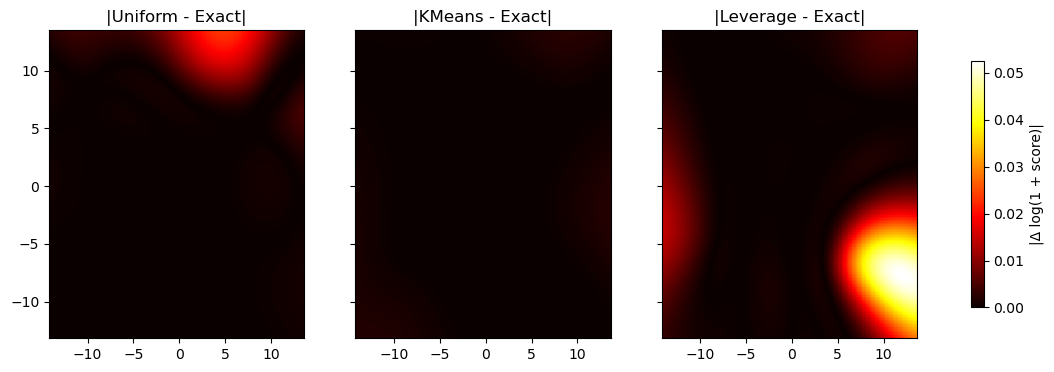

In [129]:
# --- 1x3 difference plots ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True, sharey=True)
diff_titles = ['|Uniform - Exact|', '|KMeans - Exact|', '|Leverage - Exact|']
diffs = [
    np.abs(log_uniform - log_exact),
    np.abs(log_kmeans - log_exact),
    np.abs(log_leverage - log_exact),
]

diff_vmax = max(d.max() for d in diffs)
for ax, title, diff in zip(axes, diff_titles, diffs):
    im = ax.pcolormesh(xx, yy, diff, cmap='hot', vmin=0, vmax=diff_vmax)
    ax.set_title(title)

fig.colorbar(im, ax=axes, label='|Δ log(1 + score)|', shrink=0.8)

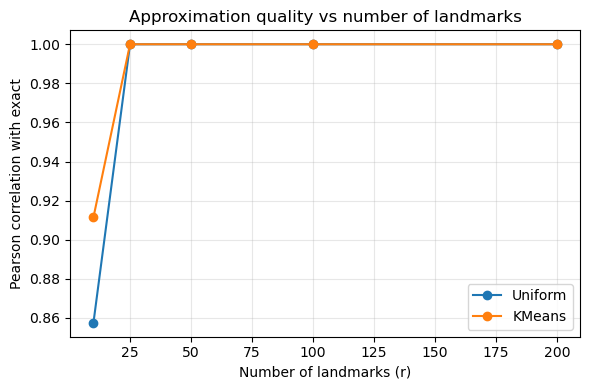

In [130]:
# --- Sensitivity: correlation vs r ---
r_values = [10, 25, 50, 100, 200]
results_sensitivity = {method: [] for method in ['Uniform', 'KMeans']}

for r_val in r_values:
    # Uniform
    idx_u = rng.choice(len(X_train), size=r_val, replace=False)
    kern_u = RBF(gamma=gamma_fixed)
    kern_u.fit(X_train)
    nys_u = NystromKernCD(kern_u, reg='adaptive', landmarks=X_train[idx_u])
    nys_u.fit(X_train)
    sc_u = nys_u.predict(X_grid)
    corr_u, _ = quality_metrics(sc_u, scores_exact)
    results_sensitivity['Uniform'].append(corr_u)

    # KMeans
    km_v = KMeans(n_clusters=r_val, random_state=0, n_init=10).fit(X_train)
    kern_k = RBF(gamma=gamma_fixed)
    kern_k.fit(X_train)
    nys_k = NystromKernCD(kern_k, reg='adaptive', landmarks=km_v.cluster_centers_)
    nys_k.fit(X_train)
    sc_k = nys_k.predict(X_grid)
    corr_k, _ = quality_metrics(sc_k, scores_exact)
    results_sensitivity['KMeans'].append(corr_k)

fig, ax = plt.subplots(figsize=(6, 4))
for method, corrs in results_sensitivity.items():
    ax.plot(r_values, corrs, 'o-', label=method)
ax.set_xlabel('Number of landmarks (r)')
ax.set_ylabel('Pearson correlation with exact')
ax.set_title('Approximation quality vs number of landmarks')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()

In [131]:
# --- Summary table ---
print(f'{"Method":20s} {"r":>5s} {"Fit (s)":>10s} {"Predict (s)":>12s} {"Corr":>8s} {"Rel RMSE":>10s}')
print('-' * 70)

rows = [
    ('Exact', 800, t_fit_exact, t_pred_exact, 1.0, 0.0),
]
for name, sc, t_f, t_p in [
    ('Uniform', scores_uniform, t_fit_uniform, t_pred_uniform),
    ('KMeans', scores_kmeans, t_fit_kmeans, t_pred_kmeans),
    ('Leverage', scores_leverage, t_fit_leverage, t_pred_leverage),
]:
    corr, rrmse = quality_metrics(sc, scores_exact)
    rows.append((name, r, t_f, t_p, corr, rrmse))

for name, rv, tf, tp, corr, rrmse in rows:
    print(f'{name:20s} {rv:5d} {tf:10.3f} {tp:12.3f} {corr:8.4f} {rrmse:10.4f}')

Method                   r    Fit (s)  Predict (s)     Corr   Rel RMSE
----------------------------------------------------------------------
Exact                  800      3.214        0.421   1.0000     0.0000
Uniform                 30      0.002        0.016   1.0000     0.0038
KMeans                  30      0.002        0.013   1.0000     0.0006
Leverage                30      0.002        0.013   1.0000     0.0115


## Observations

- **KMeans landmarks** give good correlation since centroids are well-spread across the data.
- **Leverage-weighted** sampling uses a pilot Nyström fit to estimate approximate CD scores on training points, then converts them to leverage scores via $\ell_i = 1 - \lambda \cdot \text{CD}(x_i)$. Since the Nyström approximation error is minimized by sampling proportional to leverage (Alaoui & Mahoney 2015), this favors points with **low** CD scores — structurally important points deep inside the data whose kernel vectors are well-aligned with the top eigenspace of $K$.
- **Uniform random** landmarks are cheap and work well at moderate $r$, though they don't guarantee good spatial coverage.
- The Nyström approximation gives order-of-magnitude speedups for fit (from $O(m^3)$ to $O(mr^2)$) while maintaining high correlation with exact scores.
- At $r \approx 50$–$100$ (6–12% of $m$), correlation with exact scores is typically >0.99.